<a href="https://colab.research.google.com/github/arsu5124/ai-courses/blob/main/Lane_Detection_OpenCV_AllWeather_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lane Detection in Multiple Weather Conditions - OpenCV (No Training Required)

This notebook detects **lane markings** on road images under four different conditions:
**Sunny, Rainy, Foggy, Night**

**How it works**
- Pure classical computer vision with OpenCV -- no deep learning model, no training, no dataset download.
- Since we can't rely on external image URLs being available every time (and to guarantee this notebook runs end-to-end with a single click), the notebook **synthetically generates realistic road scenes** for each of the 4 weather conditions using OpenCV drawing + noise/blur/lighting effects.
- You can also **upload your own road photos** at the bottom of the notebook -- the same pipeline will run on them.

**Pipeline used for detection**
1. Condition-aware image enhancement (CLAHE, denoising, gamma correction, detail enhancement)
2. Grayscale conversion + Gaussian blur
3. Adaptive Canny edge detection (thresholds computed from image median, so it adapts to lighting)
4. Region-of-interest (ROI) masking (trapezoid over the road area)
5. Probabilistic Hough Transform to find line segments
6. Slope/intercept averaging to fit one smooth **left lane** and one smooth **right lane**
7. Overlay of the detected lane + drivable area on the original image

**To run:** `Runtime -> Run all`. Everything below runs automatically, no setup needed (OpenCV, NumPy and Matplotlib are pre-installed in Colab).


## 1. Imports
All libraries used here (`cv2`, `numpy`, `matplotlib`) come pre-installed on Google Colab -- nothing to `pip install`.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Make plots render inline and a bit larger by default
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

print("OpenCV version:", cv2.__version__)


OpenCV version: 4.13.0


## 2. Generate Sample Road Images (Sunny / Rainy / Foggy / Night)

To keep this notebook 100% self-contained and reproducible on any machine (no broken image links, no dataset downloads),
we build a synthetic -- but realistic -- road scene with lane markings using OpenCV drawing primitives, then apply
weather-specific effects (brightness, haze, rain streaks, noise, glare) on top of the **same base scene**.

This also makes it easy to see how the *same* pipeline behaves differently depending on lighting/weather.

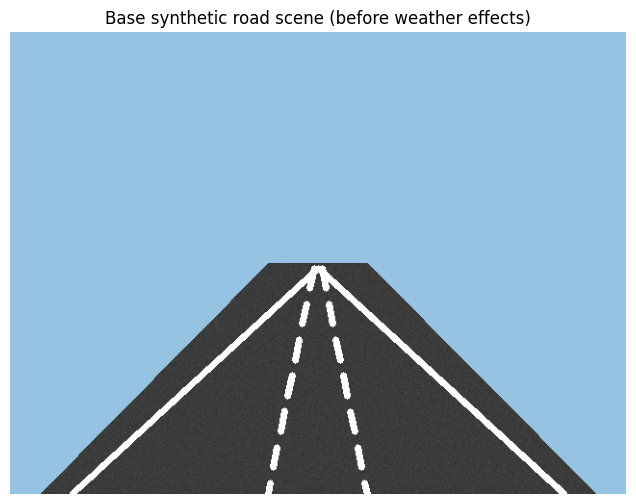

In [2]:
def draw_dashed_line(img, pt1, pt2, color, thickness=6, dash_len=22, gap_len=16):
    """Draw a dashed line between pt1 and pt2 (used for the dashed lane marking)."""
    dist = np.hypot(pt2[0] - pt1[0], pt2[1] - pt1[1])
    if dist == 0:
        return
    n_segments = int(dist / (dash_len + gap_len)) + 1
    for i in range(n_segments):
        start_r = (i * (dash_len + gap_len)) / dist
        end_r = min((i * (dash_len + gap_len) + dash_len) / dist, 1.0)
        x1 = int(pt1[0] + (pt2[0] - pt1[0]) * start_r)
        y1 = int(pt1[1] + (pt2[1] - pt1[1]) * start_r)
        x2 = int(pt1[0] + (pt2[0] - pt1[0]) * end_r)
        y2 = int(pt1[1] + (pt2[1] - pt1[1]) * end_r)
        cv2.line(img, (x1, y1), (x2, y2), color, thickness)


def create_base_road_image(width=640, height=480):
    """Create a simple but realistic base road scene: sky, asphalt, and lane markings
    converging towards a vanishing point (like a forward-facing dashcam view)."""
    img = np.zeros((height, width, 3), dtype=np.uint8)

    # --- Sky ---
    img[:] = (225, 195, 150)  # BGR light sky-blue background for whole frame first
    cv2.rectangle(img, (0, 0), (width, int(height * 0.5)), (225, 195, 150), -1)

    # --- Road (perspective trapezoid) ---
    horizon_y = int(height * 0.5)
    road_pts = np.array([
        [int(width * 0.42), horizon_y],
        [int(width * 0.58), horizon_y],
        [int(width * 0.95), height],
        [int(width * 0.05), height]
    ], np.int32)
    cv2.fillPoly(img, [road_pts], (60, 60, 60))

    # subtle asphalt texture (random speckle)
    noise = np.random.randint(-8, 8, (height, width), dtype=np.int16)
    road_mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(road_mask, [road_pts], 255)
    for c in range(3):
        channel = img[:, :, c].astype(np.int16)
        channel[road_mask == 255] += noise[road_mask == 255]
        img[:, :, c] = np.clip(channel, 0, 255).astype(np.uint8)

    # --- Lane markings ---
    vp = (int(width * 0.5), horizon_y + 5)                 # vanishing point
    left_bottom = (int(width * 0.10), height)
    right_bottom = (int(width * 0.90), height)
    center_left_bottom = (int(width * 0.42), height)
    center_right_bottom = (int(width * 0.58), height)

    # Solid outer left lane line
    cv2.line(img, vp, left_bottom, (255, 255, 255), 6)
    # Solid outer right lane line
    cv2.line(img, vp, right_bottom, (255, 255, 255), 6)
    # Dashed center-left divider
    draw_dashed_line(img, (vp[0] - 4, vp[1]), center_left_bottom, (255, 255, 255), 5)
    # Dashed center-right divider
    draw_dashed_line(img, (vp[0] + 4, vp[1]), center_right_bottom, (255, 255, 255), 5)

    return img


base_scene = create_base_road_image()
plt.imshow(cv2.cvtColor(base_scene, cv2.COLOR_BGR2RGB))
plt.title("Base synthetic road scene (before weather effects)")
plt.axis('off')
plt.show()


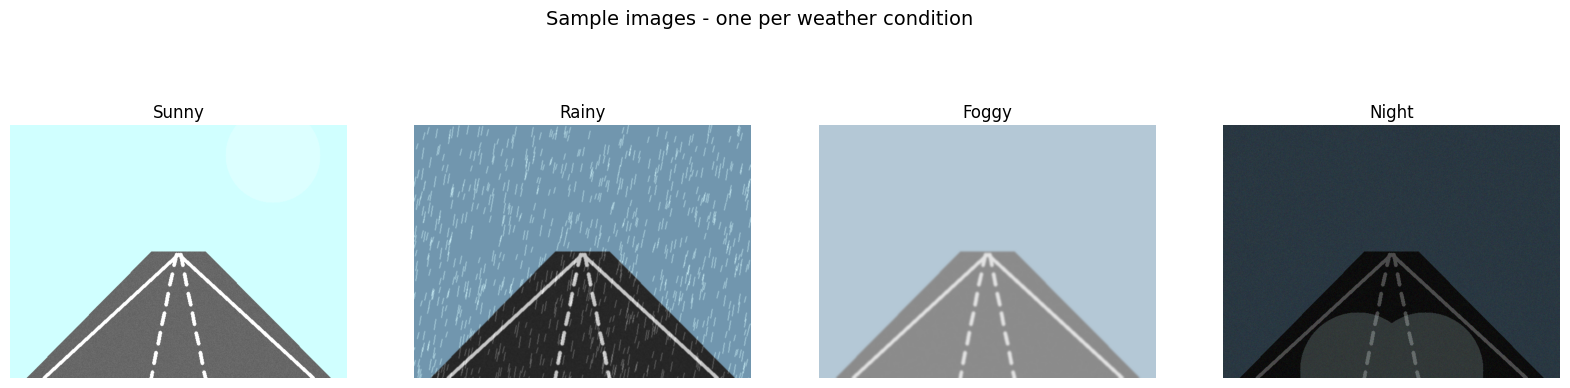

In [3]:
# ---------- Weather effect simulators ----------

def apply_sunny(img):
    """Bright daylight: higher brightness/contrast + a soft lens-glare spot."""
    out = cv2.convertScaleAbs(img, alpha=1.15, beta=35)
    glare = out.copy()
    cv2.circle(glare, (int(img.shape[1] * 0.78), int(img.shape[0] * 0.12)), 90, (255, 255, 255), -1)
    out = cv2.addWeighted(glare, 0.25, out, 0.75, 0)
    return out


def apply_rain(img, num_drops=900):
    """Rainy: slightly darker/desaturated, random rain streaks, and a light blur (wet lens/motion)."""
    out = cv2.convertScaleAbs(img, alpha=0.82, beta=-10)
    rain_layer = np.zeros_like(img)
    h, w = img.shape[:2]
    for _ in range(num_drops):
        x = np.random.randint(0, w)
        y = np.random.randint(0, h)
        length = np.random.randint(10, 22)
        cv2.line(rain_layer, (x, y), (x - 3, y + length), (200, 200, 200), 1)
    out = cv2.addWeighted(out, 1.0, rain_layer, 0.5, 0)
    out = cv2.GaussianBlur(out, (3, 3), 0)
    return out


def apply_fog(img, intensity=0.55):
    """Foggy: blend with a uniform grey/white haze layer + blur to reduce contrast and visibility."""
    fog_layer = np.full_like(img, 205)
    out = cv2.addWeighted(img, 1 - intensity, fog_layer, intensity, 0)
    out = cv2.GaussianBlur(out, (9, 9), 0)
    return out


def apply_night(img):
    """Night: heavy darkening + sensor noise + two headlight glow spots."""
    out = cv2.convertScaleAbs(img, alpha=0.32, beta=-15)
    noise = np.random.randint(0, 18, img.shape, dtype='uint8')
    out = cv2.add(out, noise)
    glow = out.copy()
    h, w = img.shape[:2]
    cv2.circle(glow, (int(w * 0.40), h - 15), 110, (255, 255, 220), -1)
    cv2.circle(glow, (int(w * 0.60), h - 15), 110, (255, 255, 220), -1)
    out = cv2.addWeighted(glow, 0.18, out, 0.82, 0)
    return out


# Build the 4 sample images from the same base scene
sample_images = {
    "Sunny":  apply_sunny(base_scene.copy()),
    "Rainy":  apply_rain(base_scene.copy()),
    "Foggy":  apply_fog(base_scene.copy()),
    "Night":  apply_night(base_scene.copy()),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, im) in zip(axes, sample_images.items()):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(name)
    ax.axis('off')
plt.suptitle("Sample images - one per weather condition", fontsize=14)
plt.show()


## 3. Condition-Aware Image Enhancement

Different weather conditions hide the lane markings in different ways, so before edge detection we apply a
light, condition-specific enhancement step:

| Condition | Problem | Fix applied |
|---|---|---|
| Sunny | Glare / blown highlights | CLAHE (adaptive local contrast) |
| Rainy | Noise + streak clutter | Denoising + CLAHE |
| Foggy | Low contrast / haze | Detail enhancement + CLAHE |
| Night | Very dark, low signal | Strong brightness boost + CLAHE |

CLAHE (Contrast Limited Adaptive Histogram Equalization) is applied to the **L channel** in LAB color space so
we boost local contrast without distorting colors.

In [4]:
def enhance_image(img, condition):
    """Apply CLAHE (always) plus a condition-specific correction."""
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    enhanced = cv2.cvtColor(cv2.merge((l_eq, a, b)), cv2.COLOR_LAB2BGR)

    condition = condition.lower()
    if condition == "night":
        # Boost brightness strongly since the raw frame is very dark
        enhanced = cv2.convertScaleAbs(enhanced, alpha=1.9, beta=35)
    elif condition == "foggy":
        # Sharpen fine details that fog tends to wash out
        enhanced = cv2.detailEnhance(enhanced, sigma_s=10, sigma_r=0.15)
    elif condition == "rainy":
        # Remove speckle/streak noise before edge detection
        enhanced = cv2.fastNlMeansDenoisingColored(enhanced, None, 6, 6, 7, 21)
    # "sunny" -> CLAHE alone is usually enough

    return enhanced


## 4. Edge Detection (Adaptive Canny)

Instead of hard-coded Canny thresholds (which fail across very different lighting conditions), we compute the
thresholds **adaptively** from the median pixel intensity of the blurred grayscale image. This makes the same
function usable for a bright sunny frame and a near-black night frame.

In [5]:
def detect_edges(img, condition):
    enhanced = enhance_image(img, condition)
    gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Adaptive Canny thresholds based on median brightness
    median_val = float(np.median(blurred))
    lower = int(max(0, 0.66 * median_val))
    upper = int(min(255, 1.33 * median_val))
    edges = cv2.Canny(blurred, lower, upper)

    return edges, enhanced


## 5. Region of Interest (ROI) Masking
We only care about edges inside the road area roughly in front of the camera -- a trapezoid shape works well for a forward-facing dashcam view and removes sky/roadside clutter.

In [6]:
def region_of_interest(edges):
    h, w = edges.shape
    mask = np.zeros_like(edges)
    polygon = np.array([[
        (int(w * 0.05), h),
        (int(w * 0.42), int(h * 0.55)),
        (int(w * 0.58), int(h * 0.55)),
        (int(w * 0.95), h),
    ]], dtype=np.int32)
    cv2.fillPoly(mask, polygon, 255)
    return cv2.bitwise_and(edges, mask)


## 6. Hough Transform + Lane Line Fitting
We detect short line segments with the Probabilistic Hough Transform, split them into **left** / **right** groups by slope sign, then average each group into a single smooth line and extrapolate it from the bottom of the image up to the horizon.

In [7]:
def make_coordinates(fits, height, y_top_ratio=0.6):
    """Convert an averaged (slope, intercept) into pixel endpoints."""
    slope, intercept = np.mean(fits, axis=0)
    if abs(slope) < 1e-3:
        return None
    y1 = height
    y2 = int(height * y_top_ratio)
    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)
    return np.array([x1, y1, x2, y2])


def average_slope_intercept(lines, height):
    """Group Hough line segments into a left lane line and a right lane line."""
    left_fit, right_fit = [], []
    if lines is None:
        return None, None

    for line in lines:
        x1, y1, x2, y2 = line[0]
        if x2 == x1:
            continue  # skip vertical segments (undefined slope)
        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1
        if abs(slope) < 0.3:
            continue  # skip near-horizontal noise (not lane-like)
        if slope < 0:
            left_fit.append((slope, intercept))
        else:
            right_fit.append((slope, intercept))

    left_line = make_coordinates(left_fit, height) if left_fit else None
    right_line = make_coordinates(right_fit, height) if right_fit else None
    return left_line, right_line


def draw_lane_overlay(img, left_line, right_line):
    """Draw the two lane lines plus a translucent green 'drivable area' between them."""
    overlay = np.zeros_like(img)

    if left_line is not None and right_line is not None:
        pts = np.array([[
            (left_line[0], left_line[1]),
            (left_line[2], left_line[3]),
            (right_line[2], right_line[3]),
            (right_line[0], right_line[1]),
        ]], dtype=np.int32)
        cv2.fillPoly(overlay, pts, (0, 180, 0))

    result = cv2.addWeighted(img, 1.0, overlay, 0.35, 0)

    for line in (left_line, right_line):
        if line is not None:
            x1, y1, x2, y2 = line
            cv2.line(result, (x1, y1), (x2, y2), (0, 255, 0), 8)

    return result


## 7. Full Pipeline
Puts every step above together into one function: enhance -> edges -> ROI -> Hough -> average -> overlay.

In [8]:
def detect_lanes(img, condition):
    """Run the full lane-detection pipeline on a single BGR image.

    Returns:
        result       - original image with detected lane overlay drawn on top
        edges        - full-frame Canny edge map (for visualization)
        roi_edges    - edge map after ROI masking (what Hough actually sees)
    """
    edges, _ = detect_edges(img, condition)
    roi_edges = region_of_interest(edges)

    lines = cv2.HoughLinesP(
        roi_edges,
        rho=2,
        theta=np.pi / 180,
        threshold=50,
        minLineLength=40,
        maxLineGap=100,
    )

    left_line, right_line = average_slope_intercept(lines, img.shape[0])
    result = draw_lane_overlay(img, left_line, right_line)

    return result, edges, roi_edges


## 8. Run on All 4 Weather Conditions + Visualize Results
For each condition we show: **original -> edge map -> final lane detection overlay**.

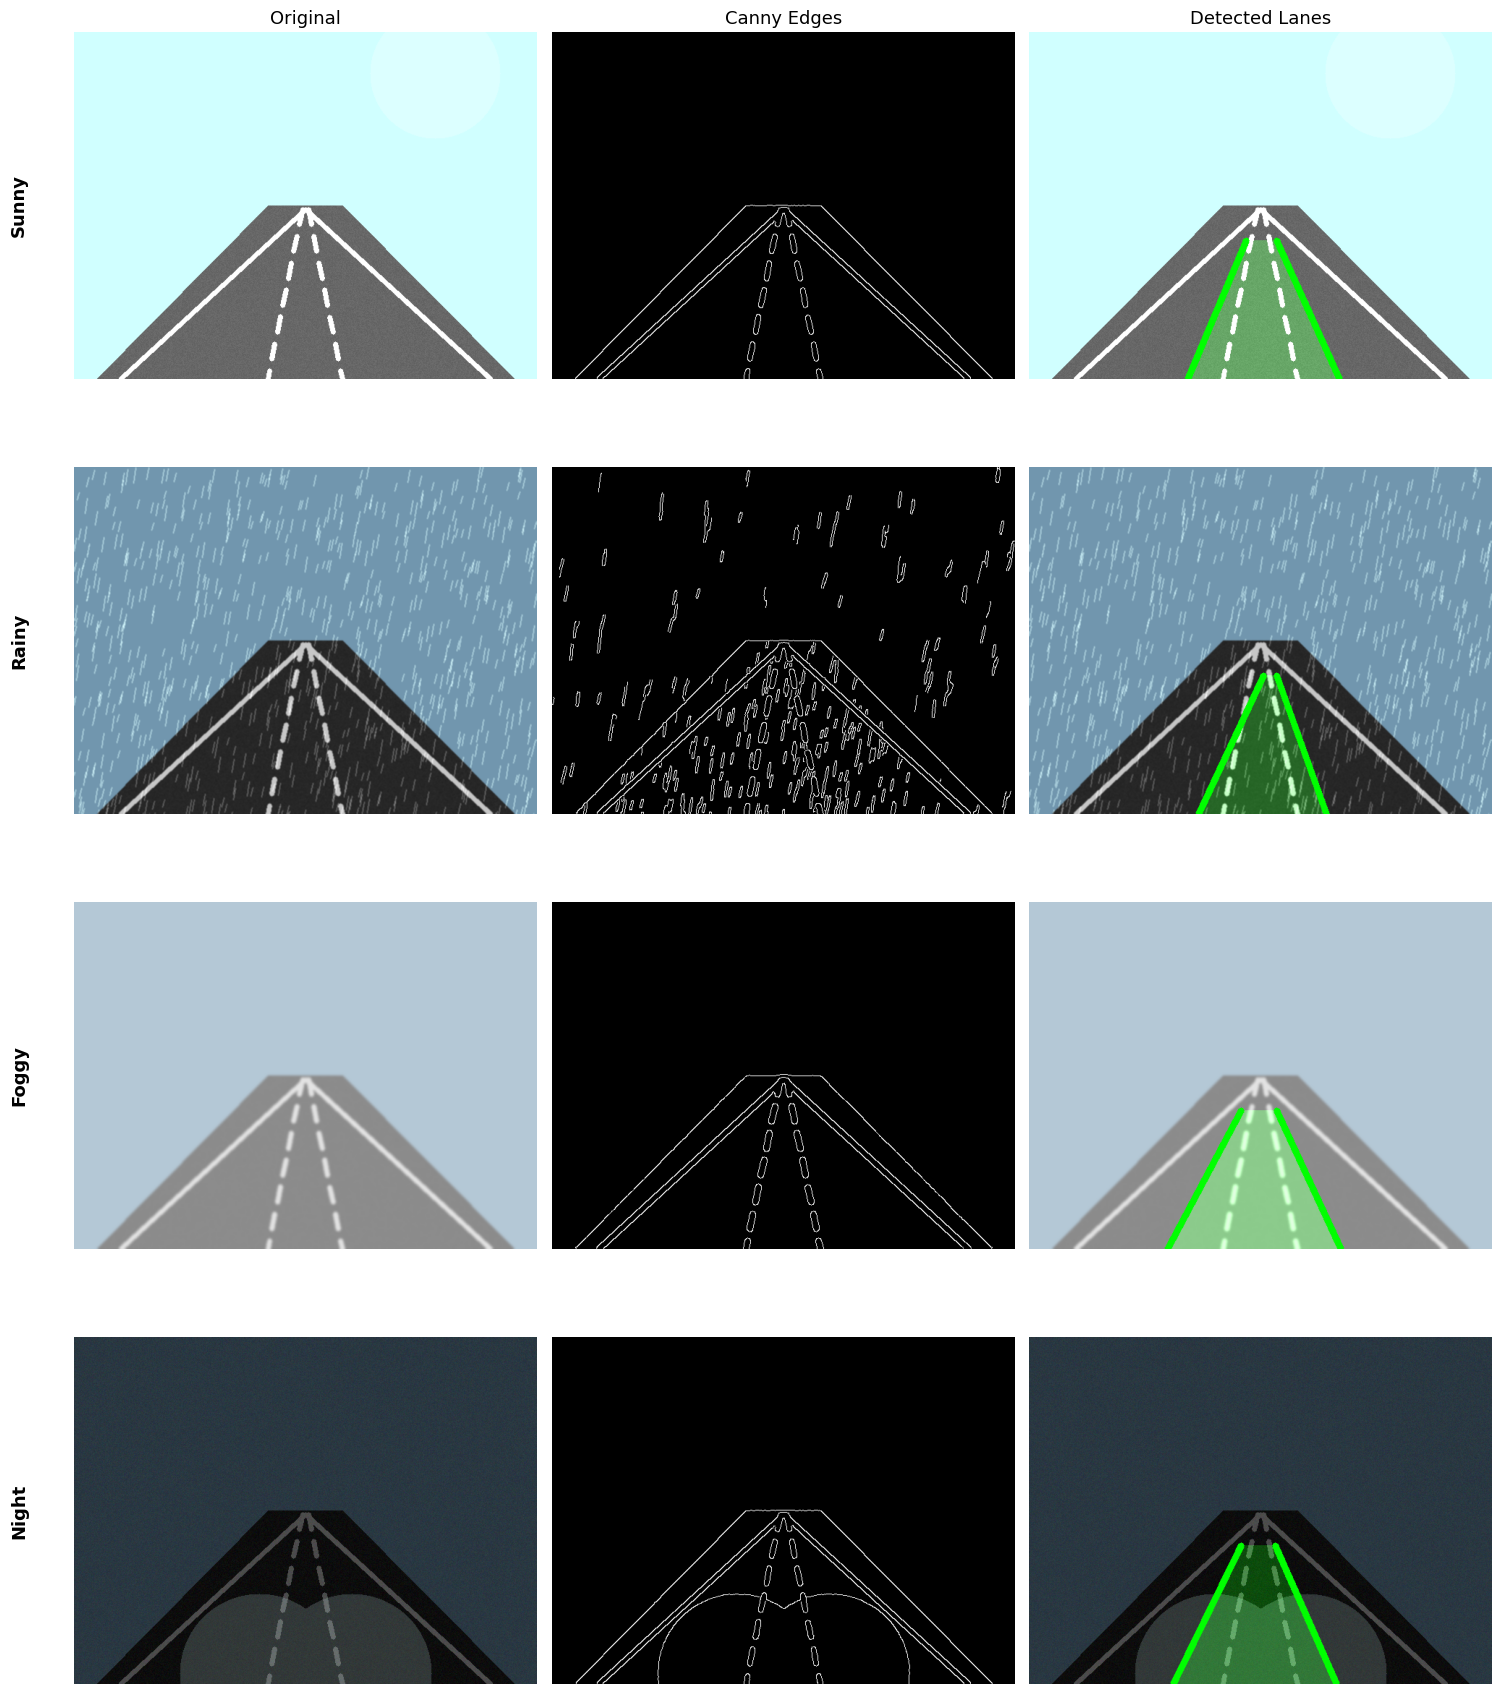

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
col_titles = ["Original", "Canny Edges", "Detected Lanes"]

for row, (condition, img) in enumerate(sample_images.items()):
    result, edges, roi_edges = detect_lanes(img, condition)

    axes[row, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[row, 1].imshow(edges, cmap='gray')
    axes[row, 2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

    for col in range(3):
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=13)

    axes[row, 0].text(-0.1, 0.5, condition, transform=axes[row, 0].transAxes,
                       fontsize=13, fontweight='bold', va='center', ha='right', rotation=90)

plt.tight_layout()
plt.show()


## 9. Try It On Your Own Photos (Optional)

Run the cell below to upload your own road image(s) -- the exact same pipeline will run on them.
For each image, tell it which condition it best matches (`sunny`, `rainy`, `foggy`, or `night`) so the
enhancement step can be tuned correctly; if unsure just use `sunny` (default/general daytime).

In [ ]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Upload one or more road images (jpg/png)...")
    uploaded = files.upload()

    for fname in uploaded.keys():
        # Guess a condition from the filename, default to 'sunny'
        lower_name = fname.lower()
        if "night" in lower_name:
            condition = "night"
        elif "fog" in lower_name:
            condition = "foggy"
        elif "rain" in lower_name:
            condition = "rainy"
        else:
            condition = "sunny"

        img = cv2.imread(fname)
        if img is None:
            print(f"Could not read {fname}, skipping.")
            continue

        result, edges, roi_edges = detect_lanes(img, condition)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original"); axes[0].axis('off')
        axes[1].imshow(edges, cmap='gray'); axes[1].set_title("Canny Edges"); axes[1].axis('off')
        axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); axes[2].set_title(f"Detected Lanes ({condition})"); axes[2].axis('off')
        plt.suptitle(fname)
        plt.show()
else:
    print("Not running inside Google Colab -- skipping the upload widget.")
    print("(This cell only activates the file-upload UI when run in a Colab environment.)")


Upload one or more road images (jpg/png)...


## Notes & Tips

- **Why classical CV instead of a pretrained deep model?** Robust open lane-detection weights (e.g. LaneNet, SCNN, Ultra-Fast-Lane-Detection) require downloading external checkpoint files, which can fail depending on network/availability. The Canny + Hough Transform approach used here needs **zero downloads and zero training**, runs instantly on CPU, and is a standard technique (used in early versions of Udacity's Self-Driving Car course) that works reasonably well on structured roads with visible lane paint.
- **Tuning per-condition:** if lanes aren't detected well on your own images, try adjusting:
  - `clipLimit` in `enhance_image()` -- more aggressive contrast boost for very dark/foggy images
  - The Canny `lower`/`upper` multipliers in `detect_edges()`
  - The ROI polygon in `region_of_interest()` -- must roughly match where the road appears in your image
  - `threshold`, `minLineLength`, `maxLineGap` in the `HoughLinesP` call -- increase `minLineLength` if you're picking up noisy short segments
- **For production-grade accuracy** (curved lanes, heavy occlusion, extreme weather) a deep-learning model trained on datasets like **TuSimple** or **CULane** will outperform this classical pipeline -- but that requires training/inference infrastructure, which this notebook deliberately avoids per the "no training required" requirement.
